# 📰 LSTM ile 20 Newsgroups Metin Sınıflandırma

> **Amaç:** 20 farklı kategoriye ait haber metinlerini LSTM tabanlı bir derin öğrenme modeli ile sınıflandırmak.
>
> **Veri Seti:** [20 Newsgroups](http://qwone.com/~jason/20Newsgroups/) — 18 846 metin, 20 kategori
>
> **Model:** `Embedding → LSTM → Dropout → Dense (Softmax)`

---

In [1]:
# Gerekli kütüphaneler (Colab için)
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


## 1. 📦 Kütüphanelerin İçe Aktarılması

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

import warnings
warnings.filterwarnings("ignore")

print("✅ Kütüphaneler başarıyla yüklendi.")

✅ Kütüphaneler başarıyla yüklendi.


## 2. 📂 Veri Setinin Yüklenmesi

`fetch_20newsgroups` ile hem eğitim hem test verileri yüklenir.

In [3]:
newsgroup     = fetch_20newsgroups(subset="all")

X = newsgroup.data          # Ham metin verileri
y = newsgroup.target        # Sayısal kategoriler (0–19)
category_names = newsgroup.target_names  # Kategori isimleri

print(f"Toplam örnek sayısı : {len(X)}")
print(f"Kategori sayısı     : {len(category_names)}")
print(f"İlk 5 kategori      : {category_names[:5]}")

Toplam örnek sayısı : 18846
Kategori sayısı     : 20
İlk 5 kategori      : ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']


## 3. 🔧 Ön İşleme

### 3.1 Hiperparametreler

In [14]:
# ── Kolayca değiştirilebilir hiperparametreler ──────────────
MAX_WORDS     = 10_000   # Sözlükte tutulacak maksimum kelime sayısı
MAX_LEN       = 100      # Her metnin sabit token uzunluğu
EMBEDDING_DIM = 64       # Embedding vektörü boyutu
LSTM_UNITS    = 32       # LSTM hücre sayısı
DROPOUT_RATE  = 0.5      # Dropout oranı
EPOCHS        = 10       # Maksimum epoch sayısı
BATCH_SIZE    = 32       # Batch büyüklüğü
PATIENCE      = 5        # EarlyStopping sabrı
NUM_CLASSES   = 20       # Çıkış sınıfı sayısı
# ────────────────────────────────────────────────────────────

### 3.2 Tokenization ve Padding

In [5]:
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X)

X_sequences = tokenizer.texts_to_sequences(X)
X_padded    = pad_sequences(X_sequences, maxlen=MAX_LEN)

print(f"Tokenization tamamlandı.")
print(f"   Girdi şekli: {X_padded.shape}  →  (örnek sayısı, dizi uzunluğu)")

Tokenization tamamlandı.
   Girdi şekli: (18846, 100)  →  (örnek sayısı, dizi uzunluğu)


### 3.3 Etiket Kodlama ve Train / Test Bölme

In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_encoded,
    test_size=0.2,
    random_state=42
)

print(f"✅ Veri bölme tamamlandı.")
print(f"   Eğitim : {X_train.shape[0]:,} örnek")
print(f"   Test   : {X_test.shape[0]:,} örnek")

✅ Veri bölme tamamlandı.
   Eğitim : 15,076 örnek
   Test   : 3,770 örnek


## 4. 📐 Özel Metrik — F1 Score

**F1 = 2 × (Precision × Recall) / (Precision + Recall)**

Multi-class için her sınıfın F1'i hesaplanır ve ortalaması alınır.

In [7]:
def f1_score(y_true, y_pred):
    """
    Multi-class F1 Score (macro-averaged).
    y_true : (batch,)      — sparse integer labels (0–19)
    y_pred : (batch, 20)   — softmax probabilities
    """
    num_classes = K.cast(K.shape(y_pred)[-1], "int32")

    # sparse integer → one-hot  (batch, 20)
    y_true_oh = K.cast(
        K.one_hot(K.cast(y_true, "int32"), num_classes),
        "float32"
    )

    # argmax → predicted class → one-hot  (batch, 20)
    y_pred_oh = K.cast(
        K.one_hot(K.cast(K.argmax(y_pred, axis=-1), "int32"), num_classes),
        "float32"
    )

    # per-class TP, FP, FN  (shape: num_classes,)
    tp = K.sum(y_true_oh * y_pred_oh, axis=0)
    fp = K.sum((1.0 - y_true_oh) * y_pred_oh, axis=0)
    fn = K.sum(y_true_oh * (1.0 - y_pred_oh), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall    = tp / (tp + fn + K.epsilon())
    f1        = 2.0 * precision * recall / (precision + recall + K.epsilon())

    return K.mean(f1)  # macro-average


## 5. 🧠 LSTM Modelinin Oluşturulması

```
Input (batch, 100)
   ↓
Embedding (batch, 100, 64)   ← kelime vektörleri
   ↓
LSTM (batch, 64)             ← bağlamı öğrenir
   ↓
Dropout 0.5                  ← overfitting engeli
   ↓
Dense 20 — Softmax           ← sınıf olasılıkları
```

In [16]:
def build_lstm_model():
    model = Sequential()

    # Embedding katmanı
    # input_dim    : sözlük büyüklüğü
    # output_dim   : kelime vektörü boyutu
    # input_length : dizi uzunluğu
    model.add(Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ))

    # LSTM katmanı — return_sequences=False: sadece son adım çıktısı
    model.add(LSTM(units=LSTM_UNITS, return_sequences=False))

    # Dropout katmanı — overfitting'i engeller
    model.add(Dropout(DROPOUT_RATE))

    # Çıkış katmanı — 20 sınıf, softmax
    model.add(Dense(NUM_CLASSES, activation="softmax"))

    # sparse_categorical_crossentropy: y_true'nun one-hot değil integer olduğunu belirtir
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy", f1_score]
    )

    return model


model = build_lstm_model()
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. 🏋️ Modelin Eğitilmesi

`EarlyStopping` ile `val_accuracy` iyileşmediğinde eğitim otomatik durur ve en iyi ağırlıklar geri yüklenir.

In [17]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

print("\n✅ Eğitim tamamlandı.")

Epoch 1/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1335 - f1_score: 0.0842 - loss: 2.7083 - val_accuracy: 0.2533 - val_f1_score: 0.1144 - val_loss: 2.2428
Epoch 2/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3032 - f1_score: 0.2016 - loss: 2.0803 - val_accuracy: 0.3966 - val_f1_score: 0.2576 - val_loss: 1.8719
Epoch 3/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4472 - f1_score: 0.3222 - loss: 1.6392 - val_accuracy: 0.4914 - val_f1_score: 0.3511 - val_loss: 1.5852
Epoch 4/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.5512 - f1_score: 0.4090 - loss: 1.3684 - val_accuracy: 0.5292 - val_f1_score: 0.3862 - val_loss: 1.4553
Epoch 5/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6312 - f1_score: 0.4741 - loss: 1.1298 - val_accuracy: 0.5889 - val_f1_score: 0.4351 - val_loss: 1.3466
Epoch 6/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6948 - f1_score: 0.5305 - loss: 0.9711 - val_accuracy: 0.6160 - val_f1_sco

## 7. 📊 Model Değerlendirmesi

In [10]:
loss, accuracy, f1 = model.evaluate(X_test, y_test, verbose=0)

print("=" * 40)
print(f"  Test Loss     : {loss:.4f}")
print(f"  Test Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Test F1 Score : {f1:.4f}")
print("=" * 40)

  Test Loss     : 1.0969
  Test Accuracy : 0.7101  (71.01%)
  Test F1 Score : 0.5497


## 8. 📈 Eğitim Geçmişinin Görselleştirilmesi

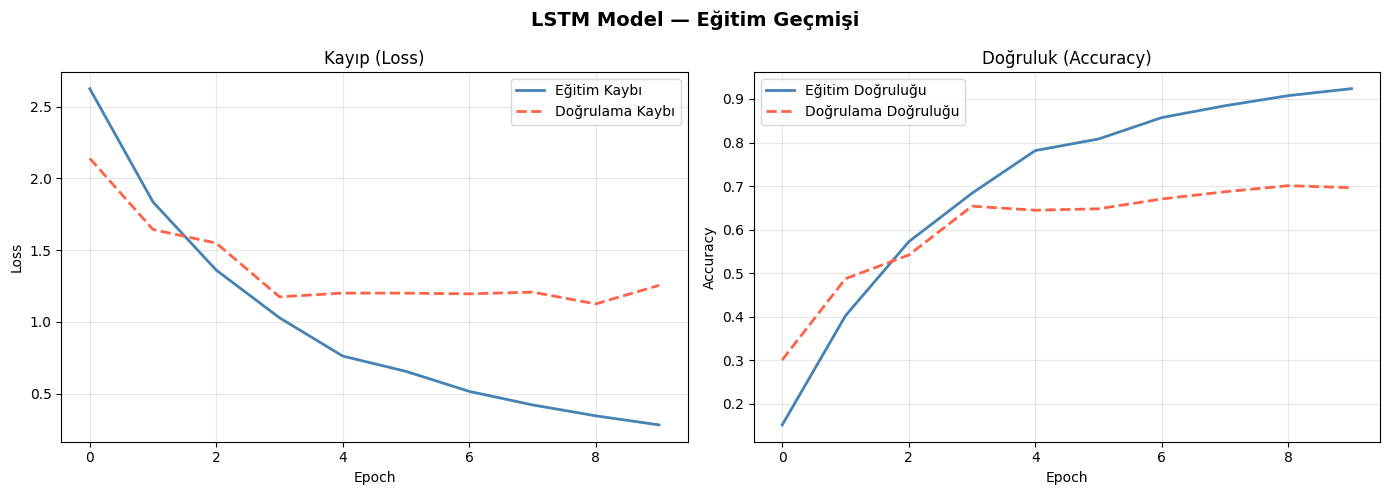

📊 Grafik 'training_history.png' olarak kaydedildi.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Model — Eğitim Geçmişi", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(history.history["loss"],     label="Eğitim Kaybı",    color="steelblue", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Doğrulama Kaybı", color="tomato",    linewidth=2, linestyle="--")
axes[0].set_title("Kayıp (Loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"],     label="Eğitim Doğruluğu",    color="steelblue", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Doğrulama Doğruluğu", color="tomato",    linewidth=2, linestyle="--")
axes[1].set_title("Doğruluk (Accuracy)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Grafik 'training_history.png' olarak kaydedildi.")

## 9. 📋 Sınıflandırma Raporu

In [12]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=category_names,
    digits=3
))

                          precision    recall  f1-score   support

             alt.atheism      0.700     0.695     0.698       151
           comp.graphics      0.540     0.743     0.625       202
 comp.os.ms-windows.misc      0.570     0.708     0.632       195
comp.sys.ibm.pc.hardware      0.507     0.612     0.554       183
   comp.sys.mac.hardware      0.767     0.595     0.670       205
          comp.windows.x      0.883     0.563     0.688       215
            misc.forsale      0.840     0.570     0.679       193
               rec.autos      0.712     0.821     0.763       196
         rec.motorcycles      0.830     0.845     0.838       168
      rec.sport.baseball      0.880     0.730     0.798       211
        rec.sport.hockey      0.808     0.894     0.849       198
               sci.crypt      0.799     0.831     0.815       201
         sci.electronics      0.598     0.604     0.601       202
                 sci.med      0.668     0.737     0.701       194
         

## 10. 🔮 Yeni Metin Tahmini

Eğitilmiş modeli istediğiniz bir metin üzerinde test edin.

In [13]:
def predict_category(text: str) -> None:
    """Verilen metni sınıflandırır ve tahmini ekrana yazdırır."""
    seq    = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)
    pred   = model.predict(padded, verbose=0)
    idx    = np.argmax(pred)

    print(f"📝 Metin   : {text[:80]}...")
    print(f"🏷️  Tahmin  : {category_names[idx]}")
    print(f"📊 Güven   : {pred[0][idx]*100:.2f}%")
    print("-" * 55)

# ── Örnek tahminler ──────────────────────────────────────────
predict_category("NASA launched a new satellite into orbit for space exploration.")
predict_category("The new GPU supports ray tracing and 4K gaming performance.")
predict_category("The government signed a major new healthcare reform bill.")

📝 Metin   : NASA launched a new satellite into orbit for space exploration....
🏷️  Tahmin  : sci.space
📊 Güven   : 99.51%
-------------------------------------------------------
📝 Metin   : The new GPU supports ray tracing and 4K gaming performance....
🏷️  Tahmin  : sci.crypt
📊 Güven   : 32.75%
-------------------------------------------------------
📝 Metin   : The government signed a major new healthcare reform bill....
🏷️  Tahmin  : talk.politics.misc
📊 Güven   : 60.50%
-------------------------------------------------------
